In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("EarthSense libraries loaded successfully!")

EarthSense libraries loaded successfully!


In [3]:
print("EarthSense is ready!")

EarthSense is ready!


In [4]:
df = pd.read_csv("EarthSense_3_Parameter_Synthetic_Data.csv")

print("Data loaded successfully!")
print("Rows:", len(df))
print("Columns:", len(df.columns))

df.head()

Data loaded successfully!
Rows: 1000
Columns: 5


,timestamp,earth_pit_id,leakage_current_A,soil_temperature_C,soil_moisture_percent
0,2026-01-01 00:00:00,EP-01,0.298,23.69,64.00
1,2026-01-01 01:00:00,EP-01,0.320,23.61,62.38
2,2026-01-01 02:00:00,EP-01,0.307,24.22,63.43
3,2026-01-01 03:00:00,EP-01,0.289,24.91,64.09
4,2026-01-01 04:00:00,EP-01,0.318,25.54,63.86


In [5]:
df["timestamp"] = pd.to_datetime(df["timestamp"])

df = df.sort_values(
    ["earth_pit_id", "timestamp"]
).reset_index(drop=True)

print("Data prepared successfully!")
print("Earth Pits:", df["earth_pit_id"].unique())

df.head()

Data prepared successfully!
Earth Pits: ['EP-01' 'EP-02' 'EP-03' 'EP-04' 'EP-05']


,timestamp,earth_pit_id,leakage_current_A,soil_temperature_C,soil_moisture_percent
0,2026-01-01 00:00:00,EP-01,0.298,23.69,64.00
1,2026-01-01 01:00:00,EP-01,0.320,23.61,62.38
2,2026-01-01 02:00:00,EP-01,0.307,24.22,63.43
3,2026-01-01 03:00:00,EP-01,0.289,24.91,64.09
4,2026-01-01 04:00:00,EP-01,0.318,25.54,63.86


In [6]:
df["days"] = (
    df.groupby("earth_pit_id")["timestamp"]
      .transform(
          lambda x: (x - x.min()).dt.total_seconds() / (24 * 60 * 60)
      )
)

df[["timestamp", "earth_pit_id", "days"]].head(10)

,timestamp,earth_pit_id,days
0,2026-01-01 00:00:00,EP-01,0.000000
1,2026-01-01 01:00:00,EP-01,0.041667
2,2026-01-01 02:00:00,EP-01,0.083333
3,2026-01-01 03:00:00,EP-01,0.125000
4,2026-01-01 04:00:00,EP-01,0.166667
5,2026-01-01 05:00:00,EP-01,0.208333
6,2026-01-01 06:00:00,EP-01,0.250000
7,2026-01-01 07:00:00,EP-01,0.291667
8,2026-01-01 08:00:00,EP-01,0.333333
9,2026-01-01 09:00:00,EP-01,0.375000


In [7]:
parameters = [
    "leakage_current_A",
    "soil_temperature_C",
    "soil_moisture_percent"
]

thresholds = {
    "leakage_current_A": 1.20,
    "soil_temperature_C": 35.0,
    "soil_moisture_percent": 30.0
}

print("Parameters:")
for p in parameters:
    print("-", p)

print("\nConfigured thresholds:")
for p, value in thresholds.items():
    print(p, "=", value)

Parameters:
- leakage_current_A
- soil_temperature_C
- soil_moisture_percent

Configured thresholds:
leakage_current_A = 1.2
soil_temperature_C = 35.0
soil_moisture_percent = 30.0


In [8]:
models = {}

for pit_id, pit_data in df.groupby("earth_pit_id"):

    models[pit_id] = {}

    for parameter in parameters:

        # Remove missing values
        clean_data = pit_data[["days", parameter]].dropna()

        X = clean_data[["days"]]
        y = clean_data[parameter]

        # Create and train model
        model = LinearRegression()
        model.fit(X, y)

        models[pit_id][parameter] = model

        print(
            f"{pit_id} | {parameter} | "
            f"Slope = {model.coef_[0]:.6f} | "
            f"Intercept = {model.intercept_:.4f}"
        )

EP-01 | leakage_current_A | Slope = 0.064191 | Intercept = 0.2999
EP-01 | soil_temperature_C | Slope = 0.065851 | Intercept = 26.7556
EP-01 | soil_moisture_percent | Slope = -2.900396 | Intercept = 64.8640
EP-02 | leakage_current_A | Slope = 0.065094 | Intercept = 0.3267
EP-02 | soil_temperature_C | Slope = 0.064039 | Intercept = 26.9267
EP-02 | soil_moisture_percent | Slope = -2.874223 | Intercept = 64.0001
EP-03 | leakage_current_A | Slope = 0.063650 | Intercept = 0.3587
EP-03 | soil_temperature_C | Slope = 0.067692 | Intercept = 27.0531
EP-03 | soil_moisture_percent | Slope = -2.921498 | Intercept = 63.5097
EP-04 | leakage_current_A | Slope = 0.064506 | Intercept = 0.3883
EP-04 | soil_temperature_C | Slope = 0.067566 | Intercept = 27.2014
EP-04 | soil_moisture_percent | Slope = -2.826232 | Intercept = 62.4028
EP-05 | leakage_current_A | Slope = 0.065015 | Intercept = 0.4189
EP-05 | soil_temperature_C | Slope = 0.067369 | Intercept = 27.3719
EP-05 | soil_moisture_percent | Slope = -2

In [9]:
metrics = []

for pit_id, pit_data in df.groupby("earth_pit_id"):

    for parameter in parameters:

        clean_data = pit_data[["days", parameter]].dropna()

        X = clean_data[["days"]]
        y = clean_data[parameter]

        model = models[pit_id][parameter]

        predictions = model.predict(X)

        mae = mean_absolute_error(y, predictions)
        rmse = np.sqrt(mean_squared_error(y, predictions))
        r2 = r2_score(y, predictions)

        metrics.append({
            "Earth Pit": pit_id,
            "Parameter": parameter,
            "MAE": mae,
            "RMSE": rmse,
            "R2 Score": r2
        })

metrics_df = pd.DataFrame(metrics)

metrics_df

,Earth Pit,Parameter,MAE,RMSE,R2 Score
0,EP-01,leakage_current_A,0.029130,0.036213,0.947870
1,EP-01,soil_temperature_C,1.778297,1.992058,0.006284
2,EP-01,soil_moisture_percent,1.388952,1.878583,0.932406
3,EP-02,leakage_current_A,0.031042,0.038229,0.943749
4,EP-02,soil_temperature_C,1.783689,1.985626,0.005983
5,EP-02,soil_moisture_percent,1.414235,1.879302,0.931206
6,EP-03,leakage_current_A,0.032441,0.039470,0.937690
7,EP-03,soil_temperature_C,1.757331,1.960033,0.006855
8,EP-03,soil_moisture_percent,1.496919,1.922141,0.930404
9,EP-04,leakage_current_A,0.028498,0.034057,0.954043


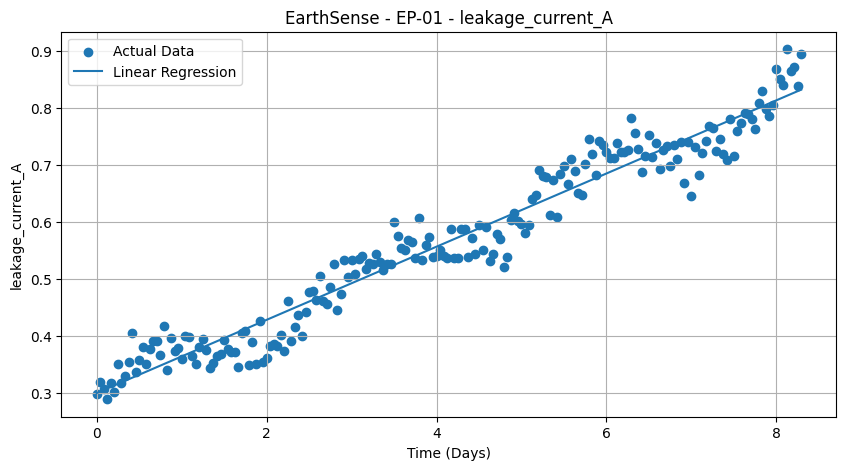

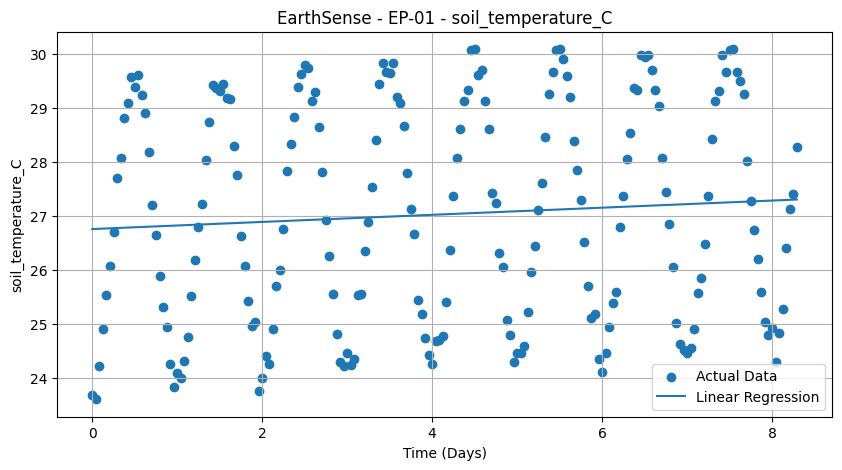

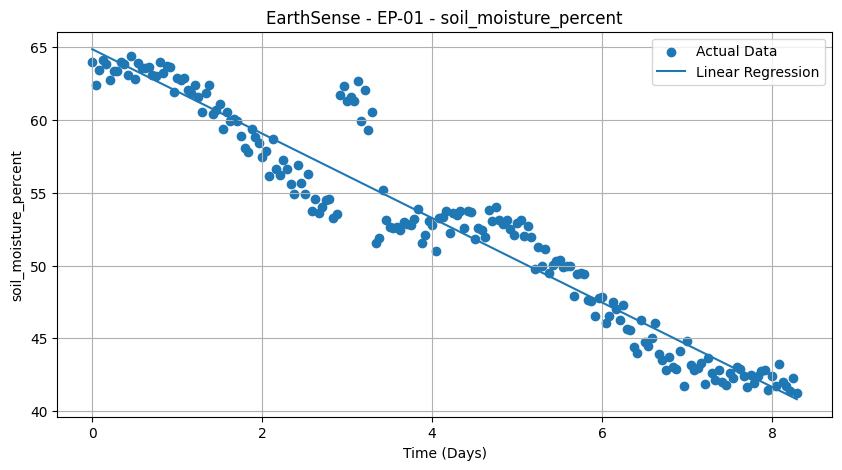

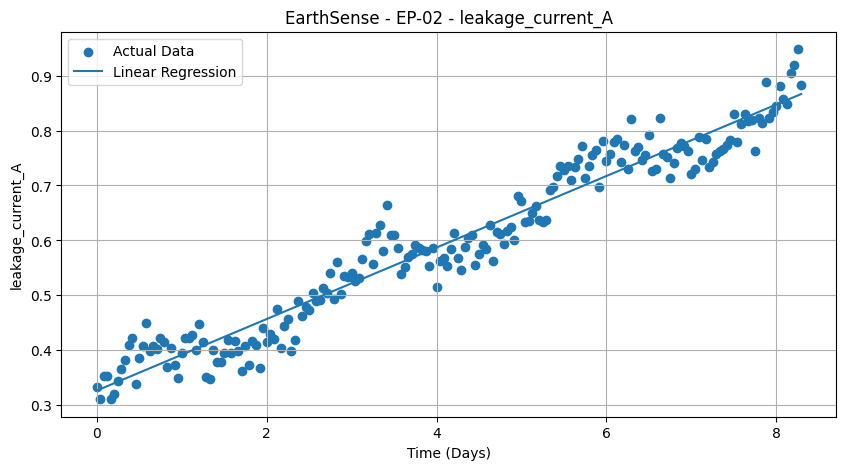

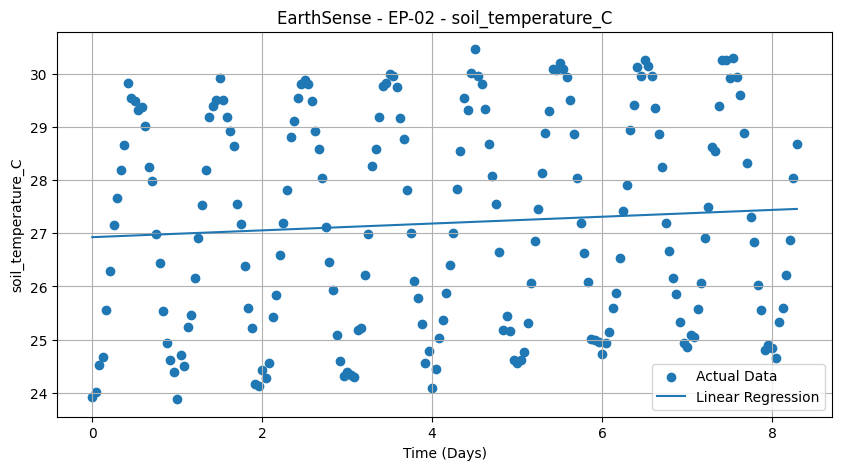

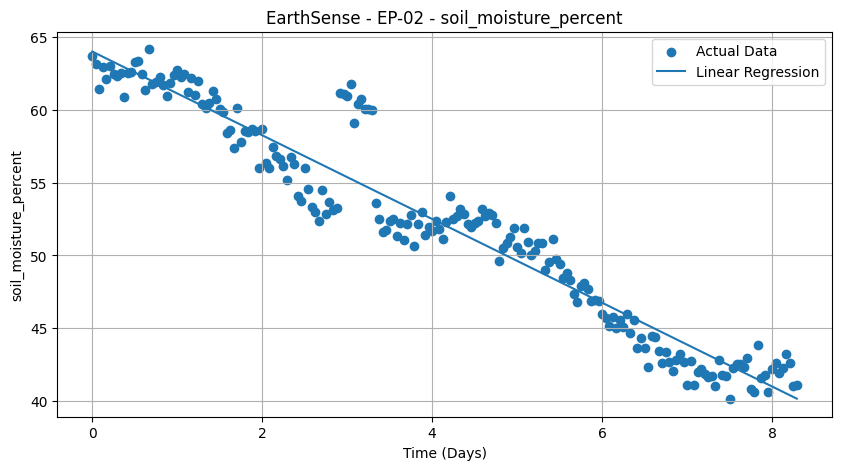

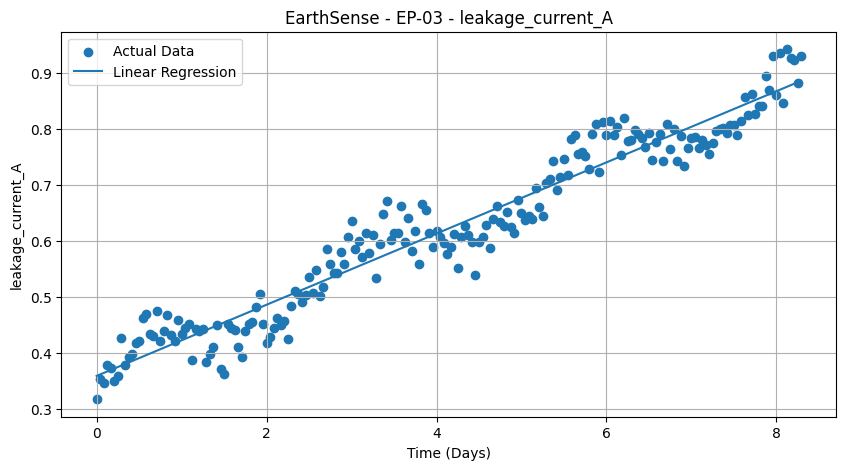

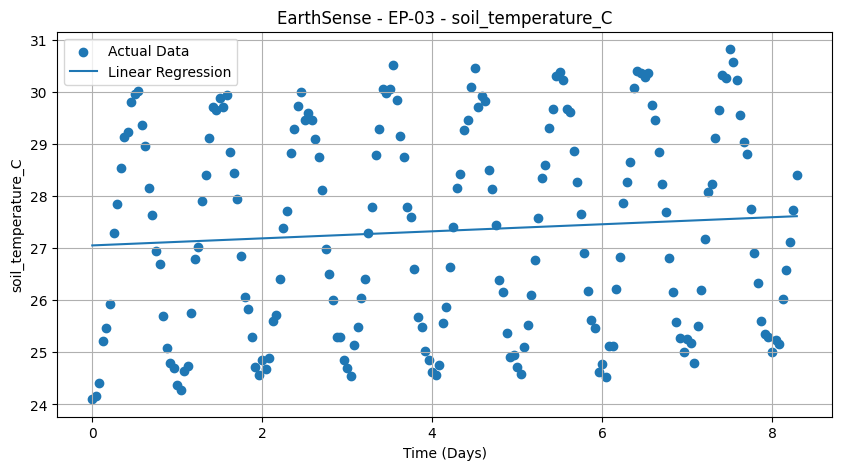

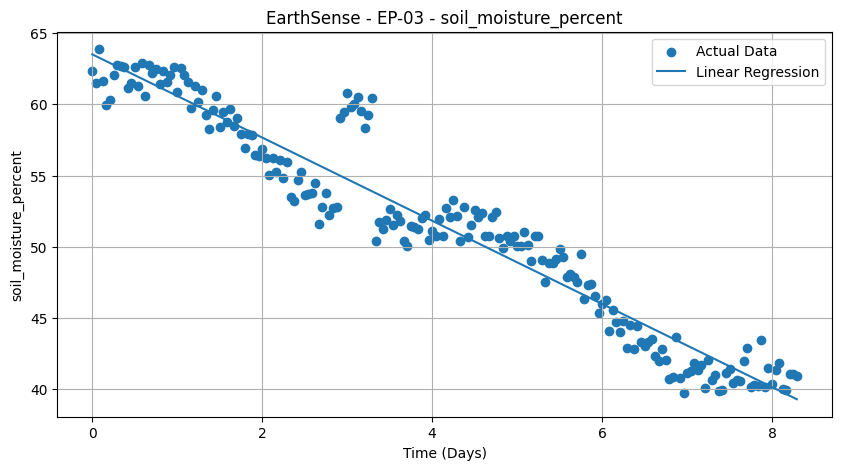

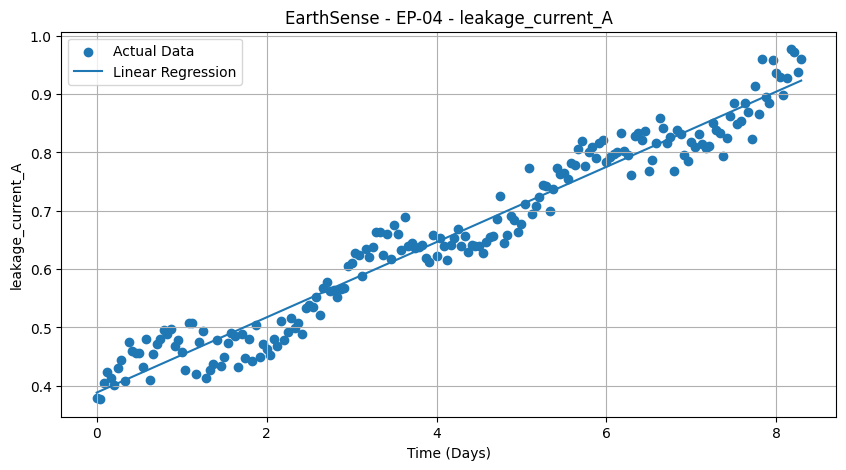

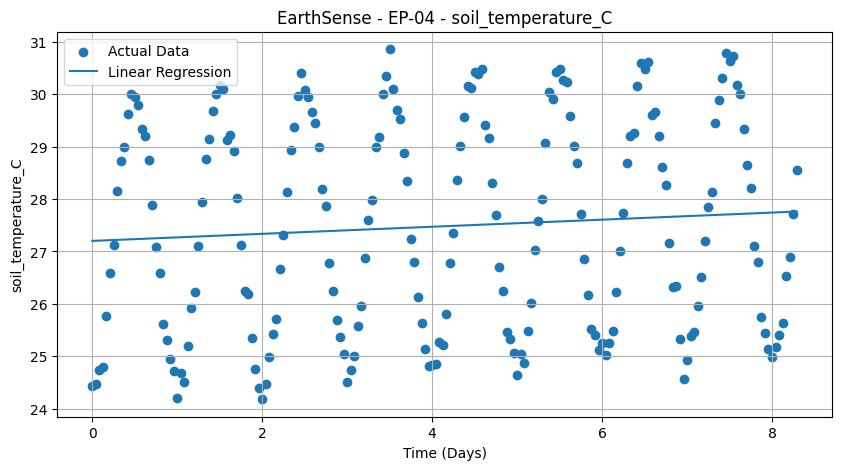

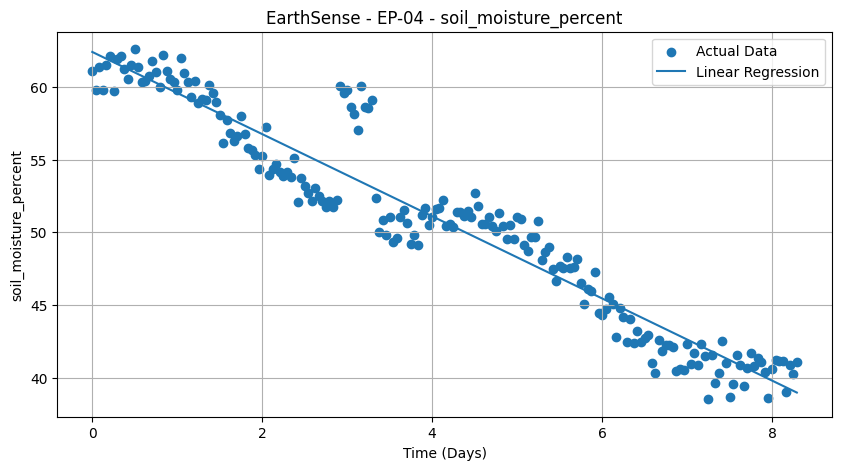

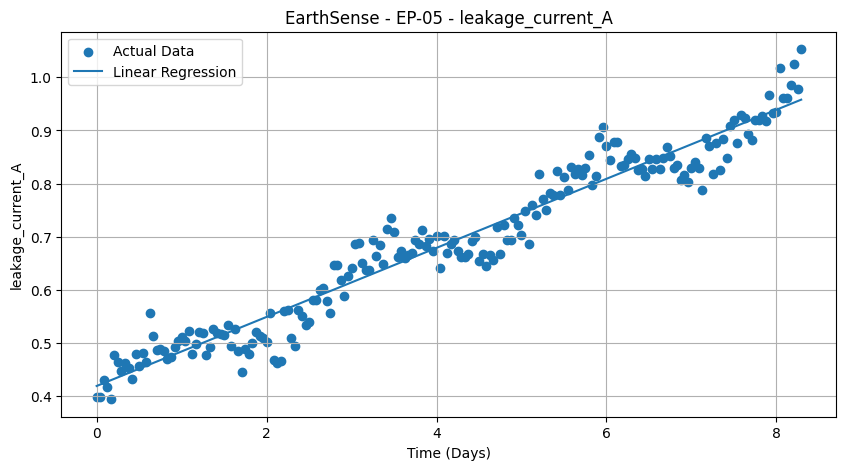

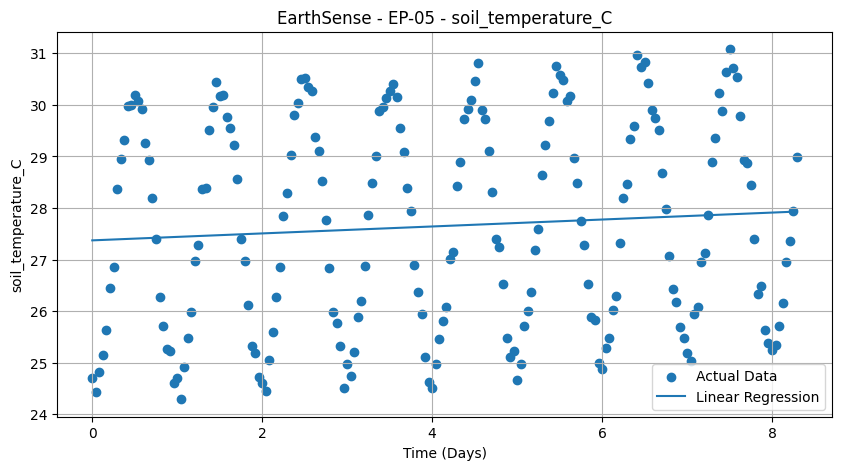

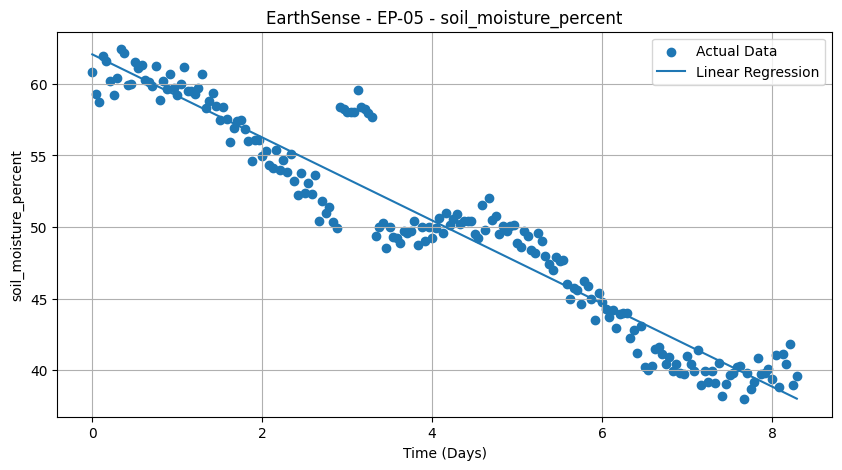

In [10]:
for pit_id, pit_data in df.groupby("earth_pit_id"):

    for parameter in parameters:

        clean_data = pit_data[["days", parameter]].dropna()

        model = models[pit_id][parameter]

        X = clean_data[["days"]]

        predicted = model.predict(X)

        plt.figure(figsize=(10, 5))

        plt.scatter(
            clean_data["days"],
            clean_data[parameter],
            label="Actual Data"
        )

        plt.plot(
            clean_data["days"],
            predicted,
            label="Linear Regression"
        )

        plt.xlabel("Time (Days)")
        plt.ylabel(parameter)

        plt.title(
            f"EarthSense - {pit_id} - {parameter}"
        )

        plt.legend()
        plt.grid(True)
        plt.show()

In [11]:
prediction_results = []

for pit_id, pit_data in df.groupby("earth_pit_id"):

    pit_data = pit_data.sort_values("timestamp")

    latest_date = pit_data["timestamp"].max()
    latest_days = pit_data["days"].max()

    for parameter in parameters:

        model = models[pit_id][parameter]

        current_data = pit_data[["days", parameter]].dropna()

        if current_data.empty:
            continue

        current_value = current_data[parameter].iloc[-1]
        slope = model.coef_[0]
        threshold = thresholds[parameter]

        days_to_critical = np.inf

        # Leakage current and temperature:
        # higher value = potentially critical
        if parameter in [
            "leakage_current_A",
            "soil_temperature_C"
        ]:

            if slope > 0 and current_value < threshold:

                days_to_critical = (
                    threshold - current_value
                ) / slope

            elif current_value >= threshold:

                days_to_critical = 0

        # Soil moisture:
        # lower value = potentially critical
        elif parameter == "soil_moisture_percent":

            if slope < 0 and current_value > threshold:

                days_to_critical = (
                    threshold - current_value
                ) / slope

            elif current_value <= threshold:

                days_to_critical = 0

        # Risk display rule for the project
        if days_to_critical == 0:
            risk = "Critical"

        elif days_to_critical <= 7:
            risk = "Warning"

        else:
            risk = "Normal"

        # Estimated date
        if np.isfinite(days_to_critical):

            critical_date = (
                latest_date +
                pd.to_timedelta(days_to_critical, unit="D")
            )

        else:

            critical_date = pd.NaT

        prediction_results.append({

            "Earth Pit": pit_id,
            "Parameter": parameter,
            "Current Value": current_value,
            "Slope per Day": slope,
            "Critical Threshold": threshold,
            "Estimated Days to Critical": days_to_critical,
            "Estimated Critical Date": critical_date,
            "Risk": risk
        })

prediction_df = pd.DataFrame(prediction_results)

prediction_df

,Earth Pit,Parameter,Current Value,Slope per Day,Critical Threshold,Estimated Days to Critical,Estimated Critical Date,Risk
0,EP-01,leakage_current_A,0.895,0.064191,1.2,4.751455,2026-01-14 01:02:05.704767430,Warning
1,EP-01,soil_temperature_C,28.270,0.065851,35.0,102.200350,2026-04-21 11:48:30.269797450,Normal
2,EP-01,soil_moisture_percent,41.270,-2.900396,30.0,3.885677,2026-01-13 04:15:22.459019967,Warning
3,EP-02,leakage_current_A,0.882,0.065094,1.2,4.885270,2026-01-14 04:14:47.310434119,Warning
4,EP-02,soil_temperature_C,28.670,0.064039,35.0,98.845551,2026-04-18 03:17:35.618174911,Normal
5,EP-02,soil_moisture_percent,41.140,-2.874223,30.0,3.875830,2026-01-13 04:01:11.748591903,Warning
6,EP-03,leakage_current_A,0.931,0.063650,1.2,4.226258,2026-01-13 12:25:48.725751239,Warning
7,EP-03,soil_temperature_C,28.410,0.067692,35.0,97.353302,2026-04-16 15:28:45.258273393,Normal
8,EP-03,soil_moisture_percent,40.930,-2.921498,30.0,3.741232,2026-01-13 00:47:22.424879097,Warning
9,EP-04,leakage_current_A,0.960,0.064506,1.2,3.720590,2026-01-13 00:17:39.013927725,Warning


In [12]:
overall_df = (
    prediction_df
    .groupby("Earth Pit")[
        "Estimated Days to Critical"
    ]
    .min()
    .reset_index()
)

overall_df.rename(
    columns={
        "Estimated Days to Critical":
        "Overall Estimated Days to Critical"
    },
    inplace=True
)

def overall_risk(days):

    if days == 0:
        return "Critical"

    elif days <= 7:
        return "Warning"

    else:
        return "Normal"

overall_df["Overall Risk"] = (
    overall_df[
        "Overall Estimated Days to Critical"
    ].apply(overall_risk)
)

overall_df

,Earth Pit,Overall Estimated Days to Critical,Overall Risk
0,EP-01,3.885677,Warning
1,EP-02,3.875830,Warning
2,EP-03,3.741232,Warning
3,EP-04,3.720590,Warning
4,EP-05,2.261007,Warning
